   AGEP  COW  SCHL  WKHP  SEX
0  18.0  1.0  18.0  21.0  2.0
1  53.0  5.0  17.0  40.0  1.0
2  41.0  1.0  16.0  40.0  1.0
3  18.0  6.0  18.0   2.0  2.0
4  21.0  5.0  19.0  50.0  1.0


/home/epigou/envs/rl/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                     Count           MSE            MAE     Mean Error
Group                                                                 
High‑Income Females   1059  6.016423e+10  208559.428079 -208559.428079
High‑Income Males     1059  4.947106e+10  177554.033577 -177307.569383


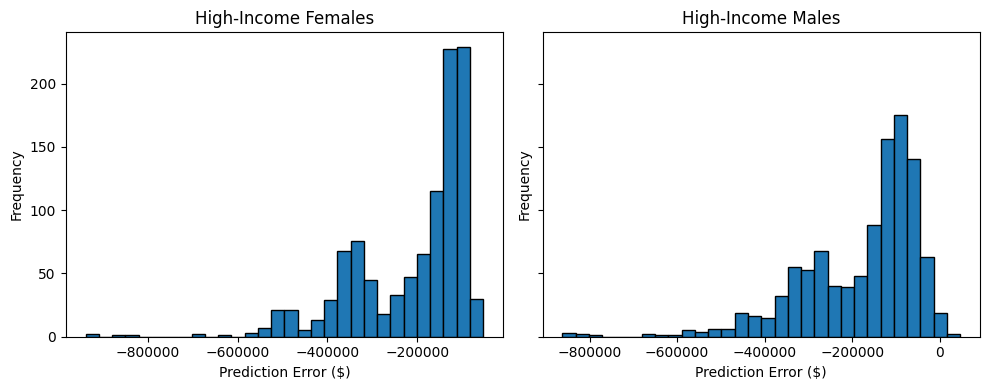

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from fairlearn.datasets import fetch_acs_income
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1) Load & prep
data_bunch = fetch_acs_income(as_frame=True)
X = data_bunch.data.iloc[:100000].drop(columns=['OCCP', 'POBP', 'RELP', 'RAC1P', 'MAR', ])
y = data_bunch.target.iloc[:100000]
print(X.head())
df = pd.concat([X, y.rename("INCOME")], axis=1)

# 2) Train/test split: test set is equal split of male/female earning >150K
INCOME = 150_000
# Identify all males and females earning >150K
high_income_mask = df['INCOME'] > INCOME
males_hi   = df[(df['SEX']==1.0) & high_income_mask]
females_hi = df[(df['SEX']==2.0) & high_income_mask]

# Find minimum count for balanced split
n_hi = min(len(males_hi), len(females_hi))

# Randomly sample n_hi from each group for test set
males_hi_test   = males_hi.sample(n=n_hi, random_state=0)
females_hi_test = females_hi.sample(n=n_hi, random_state=0)
test_idx = males_hi_test.index.union(females_hi_test.index)

# The rest is train set
train_idx = df.index.difference(test_idx)

# Split all arrays accordingly
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
sf_train, sf_test = df.loc[train_idx, ['SEX','INCOME']], df.loc[test_idx, ['SEX','INCOME']]

# 4) Fit model (FFNN)
from sklearn.neural_network import MLPRegressor
model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=200, random_state=0)
model.fit(X_train, y_train)
y_pred = pd.Series(model.predict(X_test), index=X_test.index)

# 5) Define the two slices you want
slices = {
    'High‑Income Females': (sf_test['SEX']==2.0) & (y_test > INCOME),
    'High‑Income Males'  : (sf_test['SEX']==1.0) & (y_test > INCOME),
}

# 6) Compute metrics for each slice
rows = []
for name, mask in slices.items():
    y_true = y_test[mask]
    y_hat  = y_pred[mask]
    rows.append({
        'Group':        name,
        'Count':        mask.sum(),
        'MSE':          mean_squared_error(y_true, y_hat),
        'MAE':          mean_absolute_error(y_true, y_hat),
        'Mean Error':   (y_hat - y_true).mean()
    })
metrics_df = pd.DataFrame(rows).set_index('Group')
print(metrics_df)

# 7) Plot side‑by‑side histograms of residuals
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)
for ax, (name, mask) in zip(axes, slices.items()):
    res = (y_pred - y_test)[mask]
    ax.hist(res, bins=30, edgecolor='k')
    ax.set_title(name)
    ax.set_xlabel("Prediction Error ($)")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [8]:
from scipy.stats import mannwhitneyu, ks_2samp

# Compute absolute errors for high-income females and males
errors_female = (y_pred - y_test)[(sf_test['SEX']==2.0) & (y_test > INCOME)].abs()
errors_male   = (y_pred - y_test)[(sf_test['SEX']==1.0) & (y_test > INCOME)].abs()

# Mann–Whitney U test
u_stat, p_val_u = mannwhitneyu(errors_female, errors_male, alternative="two-sided")
# Kolmogorov–Smirnov test
ks_stat, p_val_ks = ks_2samp(errors_female, errors_male)

print(f"Mann–Whitney U p‑value: {p_val_u:.3g}")
print(f"KS‑test p‑value:        {p_val_ks:.3g}")


Mann–Whitney U p‑value: 3.87e-17
KS‑test p‑value:        1.48e-27


▶ Train examples by sex:
 SEX
1.0    37084
2.0    32916
Name: count, dtype: int64 

▶ Income summary by sex:
        count          mean           std    min      25%      50%      75%  \
SEX                                                                          
1.0  37084.0  60091.690756  75777.379527  110.0  20000.0  40000.0  72110.0   
2.0  16458.0  41474.736906  50557.097532  120.0  14000.0  30000.0  52000.0   

           max  
SEX             
1.0  1290000.0  
2.0   918000.0   

▶ Numeric feature summary by sex (first 5 features):


AGEP                                                          COW  \
       count       mean        std   min   25%   50%   75%   max    count   
SEX                                                                         
1.0  37084.0  42.206154  15.502234  17.0  29.0  42.0  55.0  94.0  37084.0   
2.0  16458.0  42.535120  15.457540  17.0  29.0  43.0  55.0  94.0  16458.0   

               ...  MAR          WKHP                                         \
         mean  ...  75%  max    count       mean        std  min   25%   50%   
SEX            ...                                                             
1.0  2.163143  ...  5.0  5.0  37084.0  40.617328  13.627424  1.0  40.0  40.0   
2.0  2.086888  ...  5.0  5.0  16458.0  35.592539  12.970713  1.0  30.0  40.0   

                 
      75%   max  
SEX              
1.0  45.0  99.0  
2.0  40.0  99.0  

[2 rows x 40 columns]

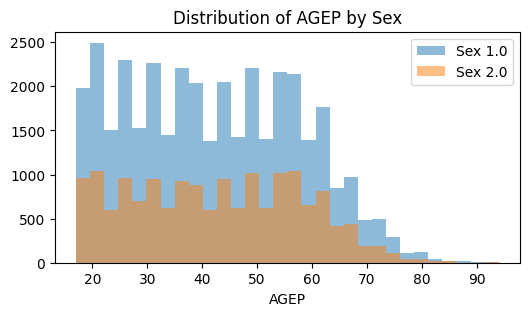

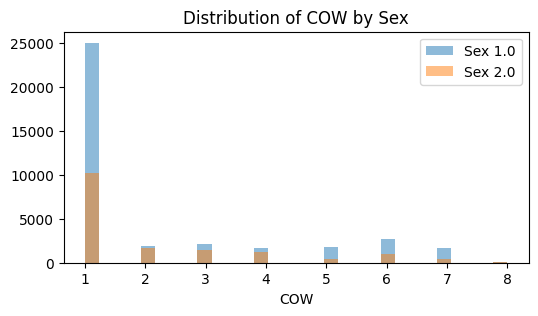

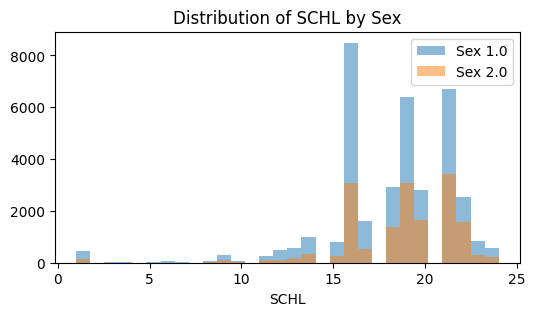

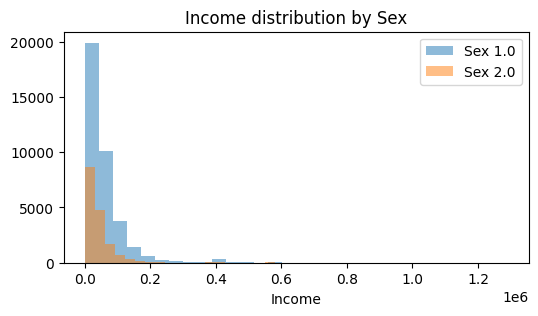

/tmp/ipykernel_3340/1140642593.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['SEX','bin'])


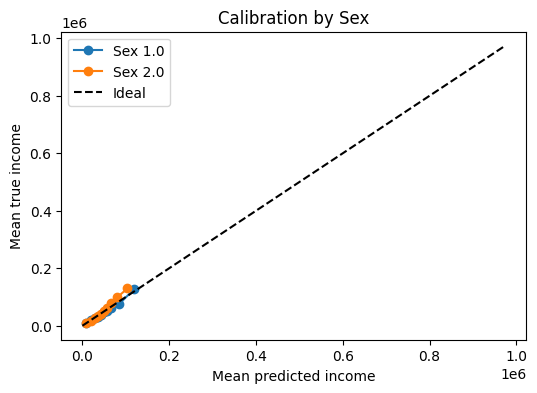

AttributeError: 'MLPRegressor' object has no attribute 'feature_importances_'

In [2]:
# ─── Diagnostic Cell: Data & Model Probing Before Synthetic Augmentation ───
#Shows under-representation of of high-income women in data which leads to error issues

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# — Assumes you already have:
#   X_train, X_test, y_train, y_test, sf_train, sf_test, and model defined —
#   where sf_train['sex'] is your sensitive feature.

# 0) (Optional) rename target for convenience
y_train = y_train.rename("income")
y_test  = y_test.rename("income")

# 1) Basic counts & summary tables
print("▶ Train examples by sex:\n", sf_train['SEX'].value_counts(), "\n")
print("▶ Income summary by sex:\n",
      pd.concat([y_train, sf_train['SEX']], axis=1)
        .groupby('SEX')['income']
        .describe(), "\n")

# Numeric feature summary (first 5 numeric columns)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
print("▶ Numeric feature summary by sex (first 5 features):")
display(
    pd.concat([X_train[numeric_cols[:5]], sf_train['SEX']], axis=1)
      .groupby('SEX')[numeric_cols[:5]]
      .describe()
)

# 2) Distribution plots for a few key features + the target
features_to_plot = list(numeric_cols[:3])  # change as needed

for col in features_to_plot:
    plt.figure(figsize=(6,3))
    for g in sf_train['SEX'].unique():
        plt.hist(
            X_train.loc[sf_train['SEX']==g, col],
            bins=30, alpha=0.5, label=f"Sex {g}"
        )
    plt.title(f"Distribution of {col} by Sex")
    plt.xlabel(col)
    plt.legend()
    plt.show()

# Target (income) distribution
plt.figure(figsize=(6,3))
for g in sf_train['SEX'].unique():
    plt.hist(
        y_train[sf_train['SEX']==g],
        bins=30, alpha=0.5, label=f"Sex {g}"
    )
plt.title("Income distribution by Sex")
plt.xlabel("Income")
plt.legend()
plt.show()

# 3) Calibration‑style plot (binned)
pred = model.predict(X_test)
df_cal = pd.DataFrame({
    'pred': pred,
    'true': y_test,
    'SEX':  sf_test['SEX']
})
df_cal['bin'] = pd.qcut(df_cal['pred'], q=10)

calib = (
    df_cal
      .groupby(['SEX','bin'])
      .agg(mean_pred=('pred','mean'),
           mean_true=('true','mean'))
      .reset_index()
)

plt.figure(figsize=(6,4))
for g in calib['SEX'].unique():
    sub = calib[calib['SEX']==g]
    plt.plot(sub['mean_pred'], sub['mean_true'], marker='o', label=f"Sex {g}")
plt.plot(
    [df_cal['true'].min(), df_cal['true'].max()],
    [df_cal['true'].min(), df_cal['true'].max()],
    'k--', label="Ideal"
)
plt.xlabel("Mean predicted income")
plt.ylabel("Mean true income")
plt.title("Calibration by Sex")
plt.legend()
plt.show()

# 4) Feature importances — overall vs. by sex
# Overall
fi = pd.Series(model.feature_importances_, index=X_train.columns)
top10 = fi.sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
top10.plot.barh()
plt.title("Top 10 Feature Importances (All Data)")
plt.gca().invert_yaxis()
plt.show()

# By‑sex importances: train small RF on each subgroup
fi_group = {}
for g in sf_train['SEX'].unique():
    mask = sf_train['SEX'] == g
    m = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=0)
    m.fit(X_train[mask], y_train[mask])
    fi_group[g] = pd.Series(m.feature_importances_, index=X_train.columns)

fi_df = pd.DataFrame(fi_group)
fi_df = fi_df.sort_values(by=fi_df.columns[0], ascending=False).head(10)

plt.figure(figsize=(6,4))
fi_df.plot.barh()
plt.title("Top 10 Importances by Sex")
plt.gca().invert_yaxis()
plt.show()


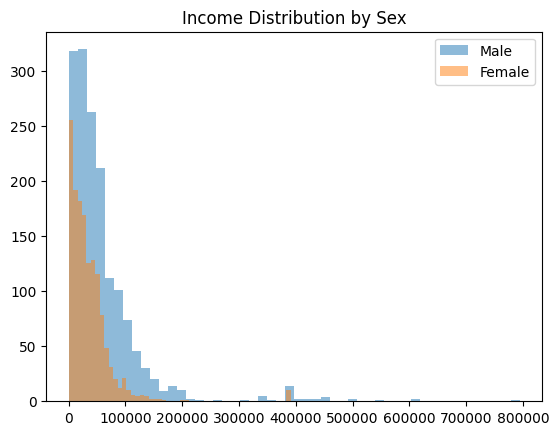

In [ ]:
# Overlay income histograms for men vs. women
sex_map = {1.0: "Male", 2.0: "Female"}
sf_test_named = sf_test['SEX'].map(sex_map)
plt.hist(y_test[sf_test_named == 'Male'], bins=50, alpha=0.5, label='Male')
plt.hist(y_test[sf_test_named == 'Female'], bins=50, alpha=0.5, label='Female')
plt.legend()
plt.title("Income Distribution by Sex")
plt.show()


Text(0.5, 1.0, 'Absolute Error (|ŷ–y|) for High‑Income (≥100K)')

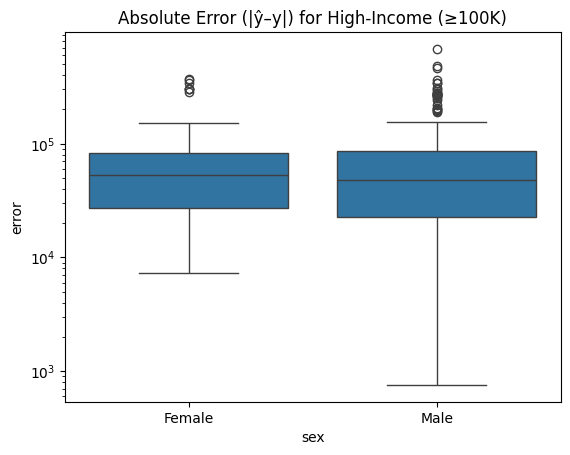

In [ ]:
# Ensure seaborn is available as sns
import seaborn as sns

df = pd.DataFrame({
  'error': np.abs(y_pred - y_test),
  'sex':   sf_test_named,
  'true_income': y_test
})
sns.boxplot(x='sex', y='error', data=df[df['true_income']>=100_000])
plt.yscale('log')
plt.title("Absolute Error (|ŷ–y|) for High‑Income (≥100K)")


{'MAE_high': [77097.79287553647, 85026.59166666666]}


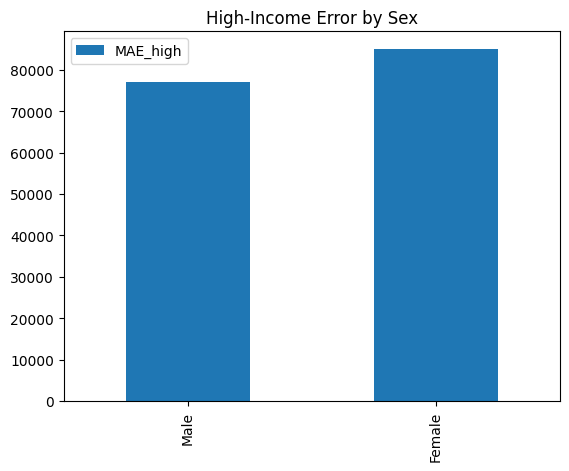

In [ ]:
# Calculate MAE and MSE for high-income (>=100K) by sex
from sklearn.metrics import mean_absolute_error, mean_squared_error

high_income_mask = y_test >= 100_000

male_mask = (sf_test_named == 'Male') & high_income_mask
female_mask = (sf_test_named == 'Female') & high_income_mask

mae_high_male = mean_absolute_error(y_test[male_mask], y_pred[male_mask])
mae_high_female = mean_absolute_error(y_test[female_mask], y_pred[female_mask])

mse_high_male = mean_squared_error(y_test[male_mask], y_pred[male_mask])
mse_high_female = mean_squared_error(y_test[female_mask], y_pred[female_mask])

metrics = {
  'MAE_high': [mae_high_male, mae_high_female]
}
print(metrics)
pd.DataFrame(metrics, index=['Male','Female']).plot.bar()
plt.title("High‑Income Error by Sex")
plt.show()
